Figure saved to: C:\Users\efc4\OneDrive - University of St Andrews\Desktop\PhD\First_Year\Projects\Fjord_Shelf_Observations\Results\thermalForcing\delta_TF_boxplot.png


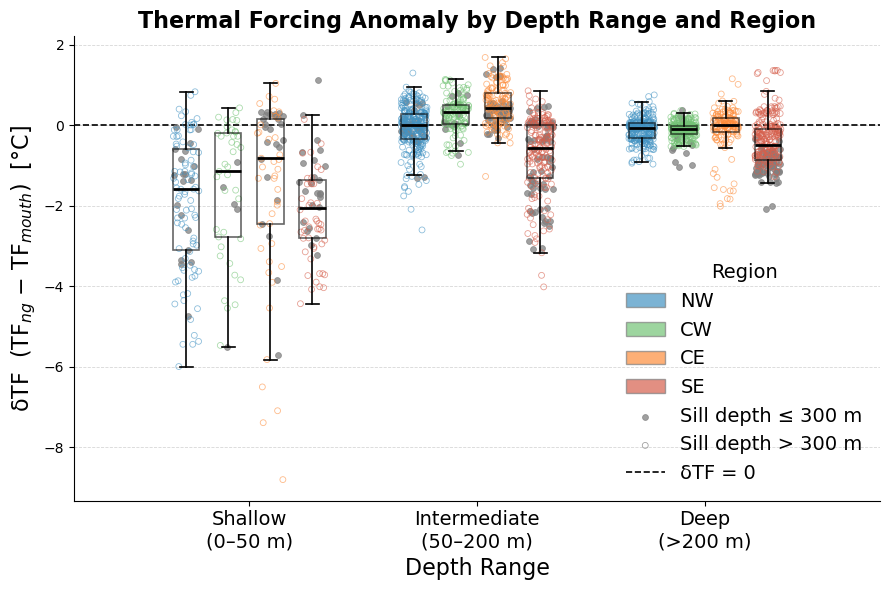

In [2]:
"""
plot_delta_TF.py

Reads the delta_TF CSV produced by save_TF_profiles.py and produces a
grouped box-and-whisker plot with:
  - X axis: 3 depth ranges (Shallow 0-50 m, Intermediate 50-200 m, Deep >200 m)
  - Y axis: delta_TF (TF_ng - TF_mouth, °C)
  - 4 boxes per depth range, one per region (NW, CW, CE, SE), colour-coded
  - Individual data points overlaid as a strip plot
  - Horizontal dashed line at delta_TF = 0
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------------------------------------------
# USER SETTINGS
# ---------------------------------------------------------------

from config_loader import load_paths
paths = load_paths()

csv_dir = paths["csv_dir"]
results_root = paths["results_dir"]

output_dir = results_root / "thermalForcing"
output_dir.mkdir(parents=True, exist_ok=True)

input_csv  = csv_dir / "delta_TF_profiles.csv"
output_fig = output_dir / "delta_TF_boxplot.png"

# ---------------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------------

REGIONS      = ["NW", "CW", "CE", "SE"]          # Order within each depth group
REGION_COLORS = {
    "NW": "#4393C3",   # blue
    "CW": "#74C476",   # green
    "CE": "#FD8D3C",   # orange
    "SE": "#D6604D",   # red
}

DEPTH_BINS = {
    "Shallow\n(0–50 m)":          (0,   50),
    "Intermediate\n(50–200 m)":   (50,  200),
    "Deep\n(>200 m)":             (200, np.inf),
}

# Spacing parameters
GROUP_WIDTH  = 1.0   # total width allocated to each depth group
BOX_WIDTH    = 0.15  # width of each individual box
GROUP_GAP    = 0.3   # gap between depth groups

# ---------------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------------

df = pd.read_csv(input_csv)
df["region"] = df["region"].str.strip().str.upper()

# ---------------------------------------------------------------
# ASSIGN DEPTH RANGE LABELS
# ---------------------------------------------------------------

def assign_depth_range(depth):
    if depth < 50:
        return "Shallow\n(0–50 m)"
    elif depth < 200:
        return "Intermediate\n(50–200 m)"
    else:
        return "Deep\n(>200 m)"

df["depth_range"] = df["depth_m"].apply(assign_depth_range)

# ---------------------------------------------------------------
# BUILD PLOT
# ---------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

depth_range_labels = list(DEPTH_BINS.keys())
n_regions = len(REGIONS)

# Centre positions for each depth group
group_centers = np.arange(len(depth_range_labels)) * (GROUP_WIDTH + GROUP_GAP)

# Offsets for each region within a group, centred around 0
offsets = np.linspace(
    -(n_regions - 1) * BOX_WIDTH * 1.6 / 2,
     (n_regions - 1) * BOX_WIDTH * 1.6 / 2,
    n_regions
)

for g_idx, depth_label in enumerate(depth_range_labels):
    group_df = df[df["depth_range"] == depth_label]

    for r_idx, region in enumerate(REGIONS):
        region_df = group_df[group_df["region"] == region].dropna(subset=["delta_TF"])
        region_data = region_df["delta_TF"].values
        sill_depths = region_df["sill_depth_m"].values

        shallow_sill = sill_depths <= 300
        deep_sill = ~shallow_sill

        x_pos = group_centers[g_idx] + offsets[r_idx]
        color = REGION_COLORS[region]

        if len(region_data) == 0:
            continue

        # --- Box and whisker ---
        bp = ax.boxplot(
            region_data,
            positions=[x_pos],
            widths=BOX_WIDTH,
            patch_artist=True,
            notch=False,
            showfliers=False,
            boxprops=dict(facecolor="none", alpha=0.6, linewidth=1.2, zorder=5),
            medianprops=dict(color="black", linewidth=2, zorder=5),
            whiskerprops=dict(color="black", linewidth=1.2, zorder=5),
            capprops=dict(color="black", linewidth=1.2, zorder=5),
            zorder=4,
        )

        # --- Strip plot overlay ---
        # Add small random horizontal jitter so points don't all overlap
        #jitter = np.zeros(len(region_data))   # no horizontal spread — pure strip
        rng = np.random.default_rng(seed=42)  # seed for reproducibility
        jitter = rng.uniform(-BOX_WIDTH / 2, BOX_WIDTH / 2, size=len(region_data))

        # Filled points — sill depth <= 300 m
        ax.scatter(
            x_pos + jitter[shallow_sill],
            region_data[shallow_sill],
            color="grey",
            edgecolors="grey",
            linewidths=0.6,
            s=18,
            alpha=0.75,
            zorder=3,
        )

        # Unfilled points — sill depth > 300 m
        ax.scatter(
            x_pos + jitter[deep_sill],
            region_data[deep_sill],
            color="none",
            edgecolors=color,
            linewidths=0.6,
            s=18,
            alpha=0.6,
            zorder=3,
        )
     
# ---------------------------------------------------------------
# ZERO LINE
# ---------------------------------------------------------------

ax.axhline(0, color="black", linewidth=1.2, linestyle="--", zorder=2, label="No change (δTF = 0)")

# ---------------------------------------------------------------
# AXES FORMATTING
# ---------------------------------------------------------------

ax.set_xticks(group_centers)
ax.set_xlim(group_centers[0] - GROUP_WIDTH, group_centers[-1] + GROUP_WIDTH)
ax.set_xticklabels(depth_range_labels, fontsize=14)
ax.set_ylabel("δTF  (TF$_{ng}$ − TF$_{mouth}$)  [°C]", fontsize=16)


ax.set_xlabel("Depth Range", fontsize=16)
ax.set_title("Thermal Forcing Anomaly by Depth Range and Region", fontsize=16, fontweight="bold")

# Remove top and right spines for a cleaner look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add light horizontal grid lines
ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# ---------------------------------------------------------------
# LEGEND
# ---------------------------------------------------------------

region_patches = [
    mpatches.Patch(facecolor=REGION_COLORS[r], edgecolor="grey", alpha=0.7, label=r)
    for r in REGIONS
]

sill_shallow = plt.scatter([], [], color="grey", edgecolors="grey", linewidths=0.6, s=18, alpha=0.75, label="Sill depth ≤ 300 m")
sill_deep    = plt.scatter([], [], color="none", edgecolors="grey", linewidths=0.6, s=18, alpha=0.75, label="Sill depth > 300 m")

zero_line = plt.Line2D([0], [0], color="black", linewidth=1.2, linestyle="--", label="δTF = 0")

ax.legend(
    handles=region_patches + [sill_shallow, sill_deep, zero_line],
    title="Region",
    frameon=False,
    fontsize=14,
    title_fontsize=14,
    loc="lower right",
)

# ---------------------------------------------------------------
# SAVE & SHOW
# ---------------------------------------------------------------

plt.tight_layout()
plt.savefig(output_fig, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {output_fig}")
plt.show()

# Now lets try plotting just the median for each fjord to stop deeper fjords being overrepresented


Figure saved to: C:\Users\efc4\OneDrive - University of St Andrews\Desktop\PhD\First_Year\Projects\Fjord_Shelf_Observations\Results\thermalForcing\delta_TF_boxplot_median_per_fjord.png


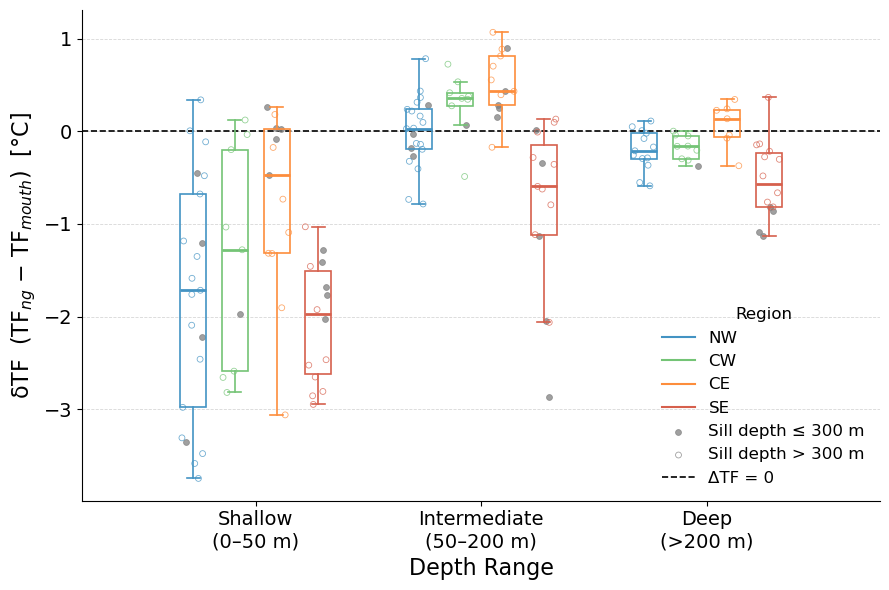

In [4]:
# ---------------------------------------------------------------
# Plot delta_TF — one median value per fjord per depth range
# ---------------------------------------------------------------
# Each circle = median delta_TF across all 10 m bins within a
# depth range for a single fjord. Reduces overrepresentation of
# deeper profiles compared to the per-bin version.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------------

REGIONS = ["NW", "CW", "CE", "SE"]
REGION_COLORS = {
    "NW": "#4393C3",
    "CW": "#74C476",
    "CE": "#FD8D3C",
    "SE": "#D6604D",
}

DEPTH_BINS = {
    "Shallow\n(0–50 m)":        (0,   50),
    "Intermediate\n(50–200 m)": (50,  200),
    "Deep\n(>200 m)":           (200, np.inf),
}

GROUP_WIDTH = 1.0
BOX_WIDTH   = 0.15
GROUP_GAP   = 0.3

# ---------------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------------

input_csv = csv_dir / "delta_TF_profiles.csv"
df = pd.read_csv(input_csv)
df["region"] = df["region"].str.strip().str.upper()

# ---------------------------------------------------------------
# ASSIGN DEPTH RANGE LABELS
# ---------------------------------------------------------------

def assign_depth_range(depth):
    if depth < 50:
        return "Shallow\n(0–50 m)"
    elif depth < 200:
        return "Intermediate\n(50–200 m)"
    else:
        return "Deep\n(>200 m)"

df["depth_range"] = df["depth_m"].apply(assign_depth_range)

# ---------------------------------------------------------------
# AGGREGATE — median delta_TF per fjord per depth range
# ---------------------------------------------------------------

df_agg = (
    df.groupby(["fjord_id", "region", "depth_range", "sill_depth_m"], as_index=False)
    ["delta_TF"]
    .median()
    .rename(columns={"delta_TF": "delta_TF_median"})
)

# ---------------------------------------------------------------
# BUILD PLOT
# ---------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

depth_range_labels = list(DEPTH_BINS.keys())
n_regions = len(REGIONS)
group_centers = np.arange(len(depth_range_labels)) * (GROUP_WIDTH + GROUP_GAP)

offsets = np.linspace(
    -(n_regions - 1) * BOX_WIDTH * 1.6 / 2,
     (n_regions - 1) * BOX_WIDTH * 1.6 / 2,
    n_regions
)

rng = np.random.default_rng(seed=42)

for g_idx, depth_label in enumerate(depth_range_labels):
    group_df = df_agg[df_agg["depth_range"] == depth_label]

    for r_idx, region in enumerate(REGIONS):
        region_df   = group_df[group_df["region"] == region].dropna(subset=["delta_TF_median"])
        region_data = region_df["delta_TF_median"].values
        sill_depths = region_df["sill_depth_m"].values

        if len(region_data) == 0:
            continue

        x_pos = group_centers[g_idx] + offsets[r_idx]
        color = REGION_COLORS[region]
        jitter = rng.uniform(-BOX_WIDTH / 2, BOX_WIDTH / 2, size=len(region_data))

        shallow_sill = sill_depths <= 300
        deep_sill    = ~shallow_sill

        # --- Box and whisker ---
        ax.boxplot(
            region_data,
            positions=[x_pos],
            widths=BOX_WIDTH,
            patch_artist=True,
            notch=False,
            showfliers=False,
            boxprops=dict(facecolor="none", linewidth=1.2, zorder=4, edgecolor=color),
            medianprops=dict(color=color, linewidth=2, zorder=5),
            whiskerprops=dict(color=color, linewidth=1.2, zorder=5),
            capprops=dict(color=color, linewidth=1.2, zorder=5),
            zorder=4,
        )

        # Filled points — sill depth <= 300 m
        ax.scatter(
            x_pos + jitter[shallow_sill],
            region_data[shallow_sill],
            color="grey",
            edgecolors="grey",
            linewidths=0.6,
            s=18,
            alpha=0.75,
            zorder=3,
        )

        # Unfilled points — sill depth > 300 m
        ax.scatter(
            x_pos + jitter[deep_sill],
            region_data[deep_sill],
            color="none",
            edgecolors=color,
            linewidths=0.6,
            s=18,
            alpha=0.75,
            zorder=3,
        )

# ---------------------------------------------------------------
# ZERO LINE
# ---------------------------------------------------------------

ax.axhline(0, color="black", linewidth=1.2, linestyle="--", zorder=2)

# ---------------------------------------------------------------
# AXES FORMATTING
# ---------------------------------------------------------------

ax.set_xticks(group_centers)
ax.set_xticklabels(depth_range_labels, fontsize=14)  
ax.set_ylabel("δTF  (TF$_{ng}$ − TF$_{mouth}$)  [°C]", fontsize=16)  
ax.set_xlabel("Depth Range", fontsize=16)  
#ax.set_title("Thermal Forcing Anomaly by Depth Range and Region\n(median per fjord)", fontsize=16, fontweight="bold")
ax.tick_params(axis='y', labelsize=14)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.5, zorder=0)
#ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.set_axisbelow(True)
ax.set_xlim(group_centers[0] - GROUP_WIDTH, group_centers[-1] + GROUP_WIDTH)

# ---------------------------------------------------------------
# LEGEND
# ---------------------------------------------------------------

region_patches = [
    plt.Line2D([0], [0], color=REGION_COLORS[r], linewidth=1.5, label=r)
    for r in REGIONS
]
sill_shallow = plt.scatter([], [], color="grey", edgecolors="grey", linewidths=0.6, s=18, alpha=0.75, label="Sill depth ≤ 300 m")
sill_deep    = plt.scatter([], [], color="none", edgecolors="grey", linewidths=0.6, s=18, alpha=0.75, label="Sill depth > 300 m")
zero_line    = plt.Line2D([0], [0], color="black", linewidth=1.2, linestyle="--", label="ΔTF = 0")

ax.legend(
    handles=region_patches + [sill_shallow, sill_deep, zero_line],
    title="Region",
    frameon=False,
    fontsize=12,
    title_fontsize=12,
    loc="lower right",
)

# ---------------------------------------------------------------
# SAVE & SHOW
# ---------------------------------------------------------------

output_fig = output_dir / "delta_TF_boxplot_median_per_fjord.png"
plt.tight_layout()
#plt.savefig(output_fig, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {output_fig}")
plt.show()